In [1]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

import os, sys
# sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
# import kuaizi
# from kuaizi.display import display_single
# kuaizi.set_env(project='SBF', name='Rosesim', data_dir='/scratch/gpfs/JENNYG/jiaxuanl/Data')
# kuaizi.set_matplotlib(style='JL', usetex=True, fontsize=18, figsize=(7, 5), dpi=90)

# sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
sys.path.append('/home/jiaxuanl/Research/Packages/romanisim/')
os.chdir('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/')

In [2]:
import asdf
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table, vstack, Column, hstack
from astropy import units as u
from astropy.visualization import simple_norm
import copy
import galsim
import roman_datamodels as rdm
from romanisim import gaia, bandpass, catalog, log, wcs, persistence, parameters, ris_make_utils as ris
from romanisim.image import inject_sources_into_l2
from romanisim.l3 import inject_sources_into_l3

Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [3]:
import os
os.environ['NUMEXPR_MAX_THREADS'] = "30"
os.environ['ROSESIM_DATA_PATH'] = "/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/"
import artpop
import rosesim
from rosesim.display import show_image_wcs
from rosesim.rose import RomanGalaxy, RomanSky
rng = np.random.RandomState(100)

## Now we already have a sky. How to include the sky into RomanGal??

In [4]:
obs_ra = 150.1049 #270.95
obs_dec = 2.2741 # -0.2

obs_ra, obs_dec = 11.8880580, -25.2888000 # NGC 253

# obs_ra, obs_dec = 201.3704160, -43.0166667 # Cen A

# obs_ra, obs_dec = 150.0763360, 2.3118682
# obs_ra, obs_dec = 150.1309765, 2.2994452
# obs_dec = 2.2832743

## Now load a Roman galaxy

In [5]:
DATA_PATH = rosesim.DATA_PATH

In [17]:
rng = np.random.RandomState(100)
log_m_star = 4
# gal_kwargs = {'age': (10**9.6) * u.yr,
#               'feh': -2,
#               'total_mass': 10**log_m_star,
#               'r_eff': 10**rosesim.mass_size_carlsten(log_m_star) / 1000 * u.kpc,
#               'distance': 10 * u.Mpc}

gal_kwargs = {'age': (10**10.1) * u.yr,
              'feh': -1,
              'total_mass': 10**log_m_star,
              'r_eff': 10**rosesim.mass_size_carlsten(log_m_star) / 1000 * u.kpc,
              'distance': 3 * u.Mpc}

gal = RomanGalaxy(prefix=f'dw_1e{log_m_star:.1f}_{gal_kwargs["distance"].to(u.Mpc).value:.1f}Mpc_age{np.log10(gal_kwargs["age"].value):.1f}_feh{gal_kwargs["feh"]:.1f}', data_dir=DATA_PATH)

reff = (gal_kwargs['r_eff'] / gal_kwargs['distance']).cgs.value * 206265
print('R_eff [arcsec]', reff)
print('15 R_eff [pix]', reff / 0.11 * 15)
s = int(reff / rosesim.pixel_scale * 15)
s = s + (s+1) % 2

dmod = 5 * np.log10(gal_kwargs['distance'].value) + 25
abs_mag_lim = 4
mag_lim = dmod + abs_mag_lim
print('mag lim', mag_lim)

R_eff [arcsec] 7.875974228908781
15 R_eff [pix] 1073.9964857602884
mag lim 31.385606273598313


In [18]:
iso = artpop.Isochrone.from_parsec(os.path.join(os.environ['ROSESIM_DATA_PATH'], 'PARSEC/PARSEC_v1.2S_Roman_vega_nTP20.dat'),
                                   log_age=np.log10(gal_kwargs['age'].to(u.yr).value), MH=gal_kwargs['feh'])
iso.mag_table.rename_columns(iso.filters, [item.replace('mag', '') for item in iso.filters])

sp = artpop.SSP(iso, total_mass=gal_kwargs['total_mass'],
                distance=gal_kwargs['distance'],
                mag_limit=mag_lim, mag_limit_band='F158',
                random_state=rng)

src = artpop.SersicSP(sp, n=0.8, theta=10 * u.deg, ellip=0.3,
                     r_eff=gal_kwargs['r_eff'], xy_dim=s, pixel_scale=rosesim.pixel_scale)

print('# of stars', src.num_stars)
print('Sampled mass fraction:', src.sp.sampled_mass / src.sp.total_mass)
# convert Vega to AB
for filt in src.mags.colnames:
    src.mags[filt] += rosesim.Roman_zp_AB_Vega_parsec[filt]

print('Total mag from stars', -2.5 * np.log10(np.sum(10**(-0.4 * src.mags['F158']))))
print('Total mag fron smooth', src.sp.mag_integrated_component('F158'))
print('SB of smooth', src.sp.mag_integrated_component('F158') + 2.5 * np.log10(2 * np.pi * src.smooth_model.r_eff.value**2 * 0.11**2))

        Use numpy.iterable() instead. [artpop.util]
2026-01-23 16:52:22 WARNING  AstropyDeprecationWarning: The isiterable function is deprecated and may be removed in a future version.
        Use numpy.iterable() instead.


        Use numpy.iterable() instead. [artpop.util]
2026-01-23 16:52:22 WARNING  AstropyDeprecationWarning: The isiterable function is deprecated and may be removed in a future version.
        Use numpy.iterable() instead.


# of stars 864
Sampled mass fraction: 0.06550566549190509
Total mag from stars 22.880160661692077
Total mag fron smooth 23.04516067034326
SB of smooth 29.5221297324672


(array([  2.,   5.,  12.,  11.,   8.,  23.,  19.,  59., 222., 503.]),
 array([-1.99053203, -1.25965378, -0.52877554,  0.20210271,  0.93298096,
         1.6638592 ,  2.39473745,  3.1256157 ,  3.85649394,  4.58737219,
         5.31825043]),
 <BarContainer object of 10 artists>)

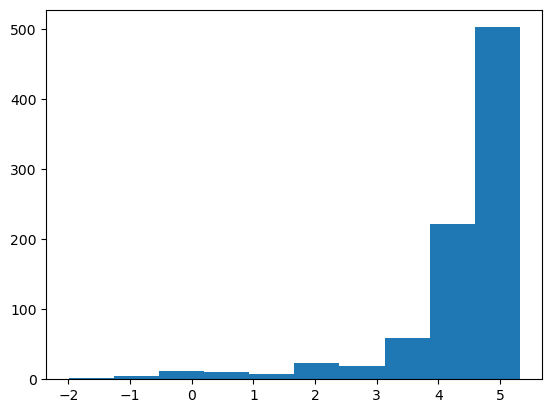

In [19]:
plt.hist(src.mags['F158'] - dmod)

(-1.0, 1.5)

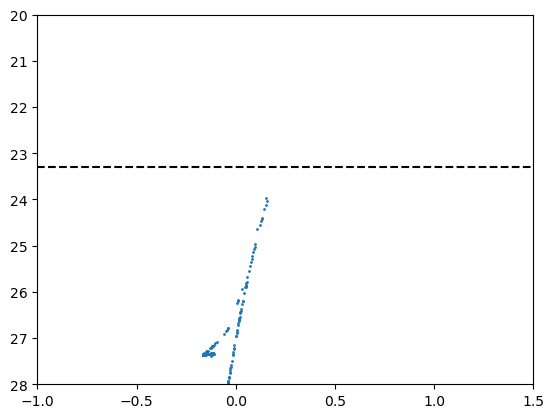

(-1.0, 1.5)

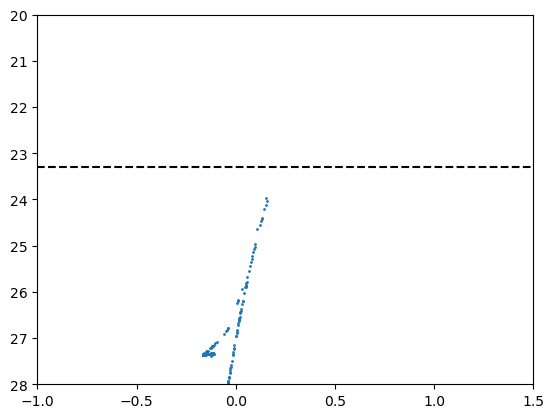

(-1.0, 1.5)

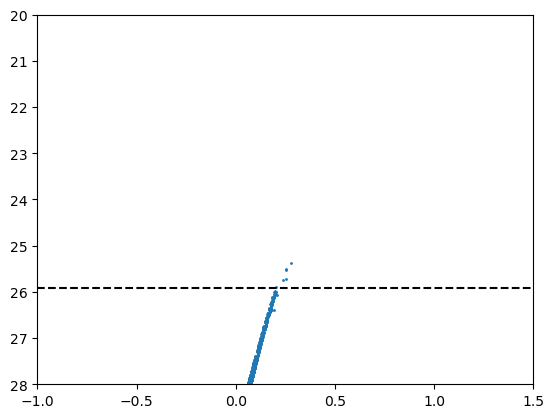

(-1.0, 1.5)

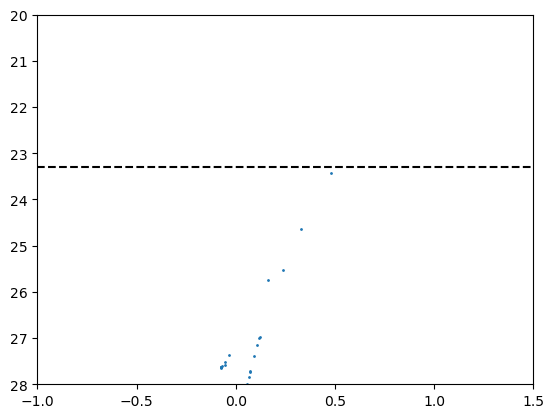

In [12]:
plt.scatter(src.mags['F106'] - src.mags['F158'], src.mags['F158'], s=1)

plt.axhline(-5.4 + sp.dist_mod + rosesim.Roman_zp_AB_Vega_parsec['F158'], ls='--', c='k')
plt.ylim(28, 20)
plt.xlim(-1, 1.5)

In [10]:
# src.sp.sbf_mag('F158') - dmod + rosesim.Roman_zp_AB_Vega_parsec['F158'], src.sp.sbf_mag('F129') - dmod + rosesim.Roman_zp_AB_Vega_parsec['F129']

In [11]:
gal.load_src(src, ra=obs_ra, dec=obs_dec)
gal.gen_catalog()

Catalogue generated.


Catalogue generated.


Catalogue generated.


In [12]:
from galsim import roman
import warnings
from copy import deepcopy
import astrocut
from astrocut import get_center_pixel, ASDFCutout
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D

In [14]:
for filt in ['F129', 'F158', 'F106']:
    t_exp = 642
    # t_exp = 10272
    gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/{filt}_{t_exp}s.asdf')
    # gal.load_bkg(filt, f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/empty_sky/{filt}_{t_exp}s.asdf')
    gal.observe(exptimes=t_exp)
    gal.dm.save(f'./{filt}_{t_exp}s.asdf')

Loaded background from /scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/F129_642s.asdf


2026-01-04 01:16:56 INFO     Setting pixscale to match default.


2026-01-04 01:16:56 WARNING  wcs is None; unlikely to get orientation of PSF correct.


2026-01-04 01:16:56 INFO     Using pupil mask 'F062' and detector 'WFI01'.


2026-01-04 01:16:56 INFO     Using pupil mask 'F062' and detector 'WFI02'.


...

2026-01-04 01:19:04 INFO      Adding extension with image downsampled to detector pixel scale.


2026-01-04 01:19:04 INFO      Downsampling to detector pixel scale, by 4


2026-01-04 01:19:04 INFO      Downsampling to detector pixel scale, by 4


2026-01-04 01:19:04 INFO     Adding 5354 sources to image...


2026-01-04 01:20:11 INFO     Rendered 5354 sources...


In [13]:
# dm = rosesim.utils.read_L3_asdf('./F158_642s.asdf')
# psf = dm.psf

In [187]:
dm = rosesim.read_L3_asdf('./F158_642s.asdf')

In [193]:
rosesim.utils.asdf_to_fits(dm, './test.fits', subtract_bkg=True)

Successfully wrote FITS file: ./test.fits


In [162]:
rosesim.asdf_to_fits(gal.dm, f'{filt}_642s.fits', subtract_bkg=True)

Successfully wrote FITS file: F158_642s.fits


# Visualize

In [15]:
cen_ra, cen_dec = 11.8880580, -25.2888000 

In [16]:
SkyCoord(obs_ra, obs_dec, unit='deg').galactic

<SkyCoord (Galactic): (l, b) in deg
    (236.73610143, 42.14961076)>

<SkyCoord (Galactic): (l, b) in deg
    (97.36384334, -87.96454679)>

<SkyCoord (Galactic): (l, b) in deg
    (97.36384334, -87.96454679)>

In [17]:
from astropy.visualization import make_lupton_rgb
import sep

zp = -2.5 * np.log10(1 * ((0.11 * u.arcsec)**2).to(u.steradian).value * 1e6 / 3631)
print(zp)

25.265227862373404


25.265227862373404


25.265227862373404


25.265227862373404


In [18]:
prefix = 'ufd_1e6_25Mpc_1.0Gyr'
# prefix = 'dw_1e5.5_20Mpc_1.0Gyr'
prefix = 'dw_1e7.0_35Mpc_0.4Gyr'
# prefix = 'ufd_1e3_2Mpc_0.4Gyr'
# prefix = 'dw_1e5.5_2Mpc_2.0Gyr'
prefix = 'dw_1e5.5_2Mpc_age9.6_feh-1.5'
prefix = 'dw_1e6.0_2Mpc_age9.6_feh-1.5'
prefix = 'dw_1e4.5_3.0Mpc_age9.6_feh-2.0'
prefix = 'dw_1e6.0_10.0Mpc_age9.6_feh-2.0'

In [19]:
# obs_ra, obs_dec = 150.0763360, 2.3118682

In [20]:
cen_ra, cen_dec = obs_ra, obs_dec
import sep

In [21]:
filters = ['F106', 'F129', 'F158']
imgs = []
# t_exp = 10272
t_exp = 642
for filt in filters:
    file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_{t_exp}s.asdf", 
    # file = f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal/{filt}_642s.asdf", 
    asdf_cutout = ASDFCutout(file,
                             SkyCoord(cen_ra, cen_dec, unit='deg'), 2048) # 5001
    # SkyCoord(obs_ra, obs_dec, unit='deg'), 4069) # 5001
    
    hdu = asdf_cutout.fits_cutouts[0]
    img = hdu[0].data
    bkg = sep.Background(img, bw=256, bh=256)
    hdu[0].data -= bkg.globalback
    hdu.writeto(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_642s_cutout.fits', overwrite=True)

    img *= 10**(0.4 * (27 - zp))
    # imgs.append(img[250:1250, :])
    imgs.append(img[:, :])

/scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/numpy/_core/numeric.py:387: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


/scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/numpy/_core/numeric.py:387: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


/scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/numpy/_core/numeric.py:387: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


In [22]:
import rosesim

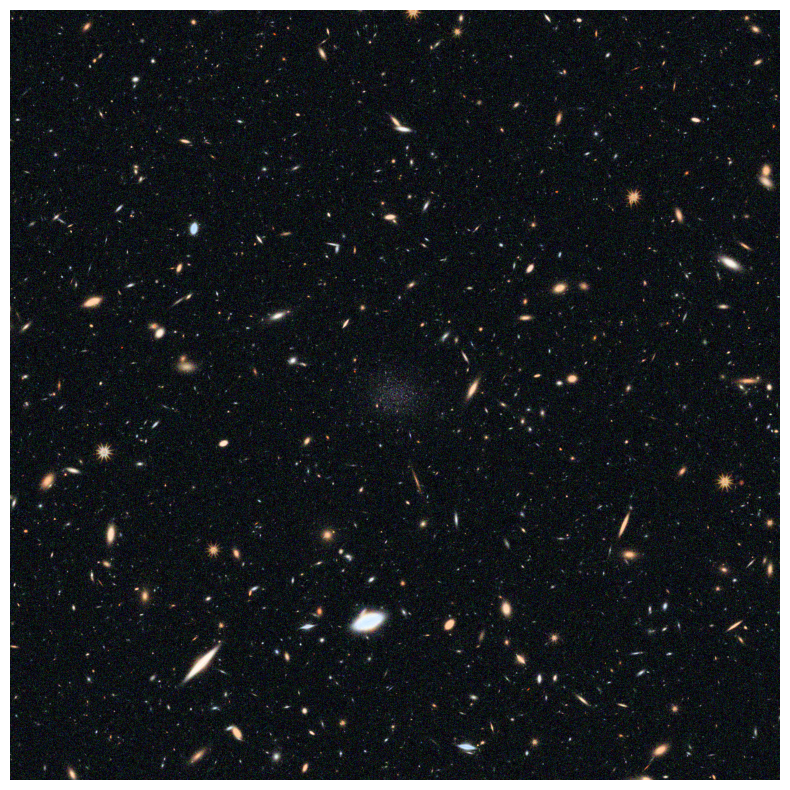

In [26]:
# rgb = make_lupton_rgb(0.95 * imgs[2], 1.15 * imgs[1], 1.2 * imgs[0], minimum=-0.02, stretch=0.2, Q=3)
rgb = make_lupton_rgb(0.9 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=0, stretch=0.5, Q=3)
fig, ax = plt.subplots(figsize=(10, 10))
# fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(rgb) #, origin='lower')
plt.axis('off')

# plt.text(wid - 0.2 * wid, +5, filters[filt_idx[0]], 
         # fontsize=20, color='deepskyblue', va='center', ha='center')
# plt.text(wid, +5, filters[filt_idx[1]], 
         # fontsize=20, color='limegreen', va='center', ha='center')
# plt.text(wid + 0.2 * wid, +5, filters[filt_idx[2]], 
         # fontsize=20, color='orangered', va='center', ha='center')
# title = prefix
# plt.title(title, fontsize=20)

plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/{prefix}.png', bbox_inches='tight', dpi=200, transparent=True, pad_inches=0)
# plt.close()

----

## Image gallery

In [275]:
for mass in [5.5, 6, 6.5, 7]:
    for dist in [50]:
        prefix = f'dw_1e{mass:.1f}_{int(dist)}Mpc_1.0Gyr'
    
        filters = ['F106', 'F129', 'F158']
        imgs = []
        for filt in filters:
            asdf_cutout = ASDFCutout(f"/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_642s.asdf", 
                                     SkyCoord(obs_ra, obs_dec, unit='deg'), 300)
        
            hdu = asdf_cutout.fits_cutouts[0]
            hdu.writeto(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/{prefix}/{filt}_642s_cutout.fits', overwrite=True)
        
            img = asdf_cutout.cutouts[0].data
            img -= np.median(img)
            img *= 10**(0.4 * (27 - zp))
            imgs.append(img[:, :])
    
        rgb = make_lupton_rgb(0.9 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=0, stretch=1, Q=3)
        fig, ax = plt.subplots(figsize=(10, 10))
        plt.imshow(rgb)
        plt.axis('off')
        plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/{prefix}.png', bbox_inches='tight', dpi=200, transparent=True)
        plt.close()

In [ ]:
from PIL import Image

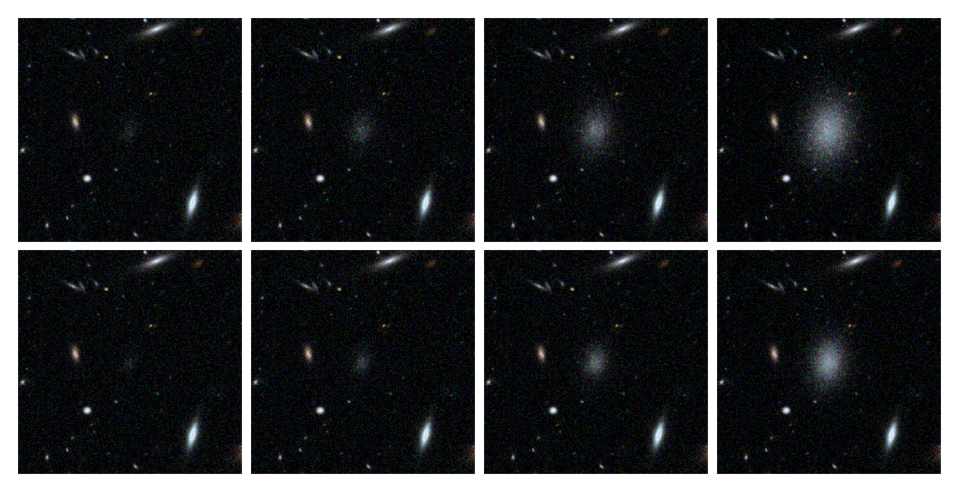

In [280]:
fig, axes = plt.subplots(2, 4, figsize=(4*2, 2*2), dpi=150)
# for ax in axes.flatten():
    # ax.axis('off')
for i, mass in enumerate([5.5, 6, 6.5, 7]):
    for j, dist in enumerate([35, 50]):
        prefix = f'dw_1e{mass:.1f}_{int(dist)}Mpc_1.0Gyr'
        file = f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/{prefix}.png'

        ax = axes[j, i]
        image = Image.open(file)
        ax.imshow(image, origin='upper')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
        # ax.text(0.05, 0.05, f'{obj['name']}', transform=ax.transAxes, ha='left', color='gray', fontsize=10)
        # ax.text(0.95, 0.85, f'{obj['stage']}', transform=ax.transAxes, ha='right', color='w', fontsize=12)
        # ax.text(0.95, 0.05, f'z={obj['z']:.4f}', transform=ax.transAxes, ha='right', color='w', fontsize=10)

plt.subplots_adjust(wspace=0.01, hspace=0.01)
plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/summary.png', bbox_inches='tight', transparent=True, dpi=200)

In [ ]:
26.5 mag in 1 pix

In [87]:
sigma = 10**(-0.4 * 26.5) / 5
sigma

5.023772863019144e-12

In [86]:
-2.5 * np.log10(sigma / np.sqrt(100 * 100))

33.24742501084005

In [88]:
10**(-0.4 * 30.5)

6.309573444801917e-13

In [90]:
sigma / 6.309573444801917e-13

7.962143411069938

---

In [13]:
import numpy as np

def flux_to_mag(flux):
    """AB-like: m = -2.5 log10(flux). Assumes flux>0."""
    flux = np.asarray(flux)
    m = np.full_like(flux, np.nan, dtype=float)
    good = flux > 0
    m[good] = -2.5 * np.log10(flux[good])
    return m

def mag_to_flux(mag):
    """Inverse of m = -2.5 log10(flux)."""
    mag = np.asarray(mag)
    return 10**(-0.4 * mag)

def apply_obs_model_two_band(
    flux_F106,
    flux_F158,
    completeness_dict,
    mag_uncertainty_dict,
    depth_HLWAS=1,
    rng=None,
    detection="both",
    ref_band="F158",
    return_flux=True,
    clip_sigma=None,
):
    """
    Forward-model incompleteness + photometric scatter for two-band photometry.

    Parameters
    ----------
    flux_F106, flux_F158 : array-like
        "True" fluxes (must be >0 to yield finite magnitudes).
    completeness_dict : dict
        e.g. {'F106': [m50, w], 'F158': [m50, w]}
    mag_uncertainty_dict : dict
        e.g. {'F106': [slope, intercept], 'F158': [slope, intercept]}
    rng : np.random.Generator, optional
        If None, uses default_rng().
    detection : {"both","either","ref"}
        - "both": require detection in both bands (common for colors).
        - "either": detected if either band is detected.
        - "ref": detected if detected in ref_band only (common for detection image).
    ref_band : {"F106","F158"}
        Used only if detection="ref".
    return_flux : bool
        If True, also return noisy fluxes computed from noisy magnitudes.
    clip_sigma : float or None
        If set, clip magnitude perturbations to +/- clip_sigma * sigma_m (rarely needed).

    Returns
    -------
    out : dict
        Keys include:
          - 'detected' (bool mask)
          - 'm_true_F106', 'm_true_F158'
          - 'm_obs_F106', 'm_obs_F158' (NaN if not detected)
          - optionally 'flux_obs_F106', 'flux_obs_F158'
          - 'sigma_m_F106', 'sigma_m_F158' (evaluated at m_true)
          - 'pdet_F106', 'pdet_F158'
    """
    if rng is None:
        rng = np.random.default_rng()

    flux_F106 = np.asarray(flux_F106, dtype=float)
    flux_F158 = np.asarray(flux_F158, dtype=float)

    # True magnitudes
    m_true_F106 = flux_to_mag(flux_F106)
    m_true_F158 = flux_to_mag(flux_F158)

    delta_mag = 1.25 * np.log10(depth_HLWAS)
    # Detection probabilities from completeness curves (evaluated at true mags)
    pdet_F106 = logistic_completeness(m_true_F106 - delta_mag, *completeness_dict["F106"])
    pdet_F158 = logistic_completeness(m_true_F158 - delta_mag, *completeness_dict["F158"])

    # Realize detections (Bernoulli trials)
    det_F106 = rng.random(size=m_true_F106.size) < pdet_F106
    det_F158 = rng.random(size=m_true_F158.size) < pdet_F158

    if detection == "both":
        detected = det_F106 & det_F158
    elif detection == "either":
        detected = det_F106 | det_F158
    elif detection == "ref":
        if ref_band == "F106":
            detected = det_F106
        elif ref_band == "F158":
            detected = det_F158
        else:
            raise ValueError("ref_band must be 'F106' or 'F158'")
    else:
        raise ValueError("detection must be one of {'both','either','ref'}")

    # Photometric uncertainty model (evaluated at true mags)
    sigma_m_F106 = mag_uncertainty_func(m_true_F106 - delta_mag, *mag_uncertainty_dict["F106"])
    sigma_m_F158 = mag_uncertainty_func(m_true_F158 - delta_mag, *mag_uncertainty_dict["F158"])

    # Initialize observed mags as NaN (non-detections remain missing)
    m_obs_F106 = np.full_like(m_true_F106, np.nan, dtype=float)
    m_obs_F158 = np.full_like(m_true_F158, np.nan, dtype=float)

    # Draw perturbations for detected objects only
    idx = np.where(detected)[0]
    if idx.size > 0:
        dm106 = rng.normal(loc=0.0, scale=sigma_m_F106[idx])
        dm158 = rng.normal(loc=0.0, scale=sigma_m_F158[idx])

        if clip_sigma is not None:
            dm106 = np.clip(dm106, -clip_sigma * sigma_m_F106[idx], clip_sigma * sigma_m_F106[idx])
            dm158 = np.clip(dm158, -clip_sigma * sigma_m_F158[idx], clip_sigma * sigma_m_F158[idx])

        m_obs_F106[idx] = m_true_F106[idx] + dm106
        m_obs_F158[idx] = m_true_F158[idx] + dm158

    out = dict(
        detected=detected,
        m_true_F106=m_true_F106,
        m_true_F158=m_true_F158,
        m_obs_F106=m_obs_F106,
        m_obs_F158=m_obs_F158,
        sigma_m_F106=sigma_m_F106,
        sigma_m_F158=sigma_m_F158,
        pdet_F106=pdet_F106,
        pdet_F158=pdet_F158,
    )
    return out


In [14]:
cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253_sizecut/temp/sky_table.ecsv')
cat = cat[cat['half_light_radius'] < 0.15]
# flag = flux_to_mag(cat['F158']) < 27
# cat = cat[flag]

# Dwarf “member” stars (your red points)
m158_g = flux_to_mag(gal.obj_cat['F158'])
c_g    = flux_to_mag(gal.obj_cat['F106']) - flux_to_mag(gal.obj_cat['F158'])  # (F106 - F158)

# Background sources (your black points; SER subset)
m158_b = flux_to_mag(cat['F158'])
c_b    = flux_to_mag(cat['F106'] / cat['F158'])  # equivalent to mag(F106)-mag(F158)

Text(0, 0.5, 'Dec')

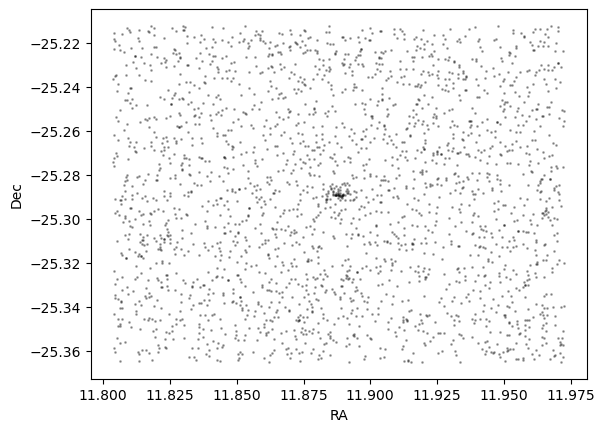

In [20]:
# plt.scatter(cat['ra'], cat['dec'], s=1, c='k', alpha=0.3)
plt.scatter(cat['ra'][inside], cat['dec'][inside], s=1, c='k', alpha=0.3)

flag = -2.5 * np.log10(gal.obj_cat['F158']) < 27
plt.scatter(gal.obj_cat['ra'][flag], gal.obj_cat['dec'][flag], s=1, c='k', alpha=0.3)

plt.xlabel('RA')
plt.ylabel('Dec')

In [18]:
from scipy.spatial import cKDTree

dmag = 0.1
dcol = 0.2

# Rescale axes so that "1 unit" corresponds to your tolerance in each axis.
X_g = np.column_stack([c_g / dcol,  m158_g / dmag])
X_b = np.column_stack([c_b / dcol,  m158_b / dmag])

tree = cKDTree(X_g)
dist, _ = tree.query(X_b, k=1)

# dist < 1 means within an ellipse: (Δcolor/dcol)^2 + (Δmag/dmag)^2 < 1
inside = dist < 0.6

sel_m158_b = m158_b[inside]
sel_c_b    = c_b[inside]

Text(0, 0.5, 'F158')

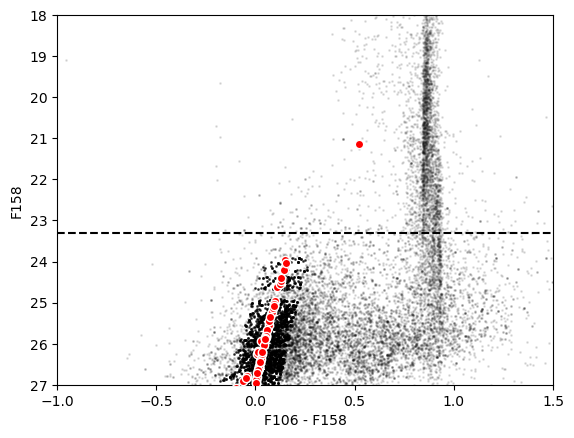

Text(0, 0.5, 'F158')

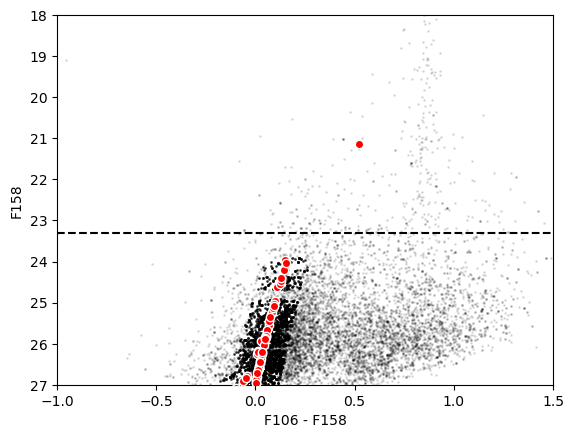

In [19]:
plt.scatter(c_g, m158_g, color='r', zorder=10, ec='w')

plt.scatter(c_b, m158_b, c='k', alpha=0.1, s=1)
plt.scatter(sel_c_b, sel_m158_b, c='k', alpha=0.6, s=1)

plt.axhline(-5.4 + sp.dist_mod + rosesim.Roman_zp_AB_Vega_parsec['F158'], ls='--', c='k')

plt.ylim(27, 18)
plt.xlim(-1, 1.5)

plt.xlabel('F106 - F158')
plt.ylabel('F158')

In [21]:
def logistic_completeness(m, m50, w):
    return 1.0 / (1.0 + np.exp((m - m50) / w))

def mag_uncertainty_func(m, slope, intercept):
    return 10**(m * slope + intercept)

completeness_dict = {'F158': [26.265128309473074, 0.20950393512684282], 
                     'F106': [26.65420231875137, 0.24173024529576023]} # HLWAS depth
mag_uncertainty_dict = {'F158': [0.37152117, -10.49171066], 
                        'F106': [0.38426587, -10.92600549]} # HLWAS depth

In [22]:
rng = np.random.default_rng(123)
depth_HLWAS = 8

# Ultra-faint dwarf sources
ufd = apply_obs_model_two_band(
    gal.obj_cat["F106"], gal.obj_cat["F158"],
    completeness_dict=completeness_dict,
    mag_uncertainty_dict=mag_uncertainty_dict,
    rng=rng,
    detection="both",     # since you care about colors
    return_flux=True,
    depth_HLWAS=depth_HLWAS
)

# Background sources (same forward model)
bkg = apply_obs_model_two_band(
    cat["F106"], cat["F158"],
    completeness_dict=completeness_dict,
    mag_uncertainty_dict=mag_uncertainty_dict,
    rng=rng,
    detection="both",
    return_flux=True,
    depth_HLWAS=depth_HLWAS
)

In [23]:
# Ultra-faint dwarf
mask_ufd = np.isfinite(ufd["m_obs_F106"]) & np.isfinite(ufd["m_obs_F158"])
c_ufd = ufd["m_obs_F106"][mask_ufd] - ufd["m_obs_F158"][mask_ufd]
m_ufd = ufd["m_obs_F158"][mask_ufd]

# Background
mask_bkg = np.isfinite(bkg["m_obs_F106"]) & np.isfinite(bkg["m_obs_F158"])
c_bkg = bkg["m_obs_F106"][mask_bkg] - bkg["m_obs_F158"][mask_bkg]
m_bkg = bkg["m_obs_F158"][mask_bkg]


In [24]:
from scipy.spatial import cKDTree

dmag = 0.2
dcol = 0.3

# Rescale axes so that "1 unit" corresponds to your tolerance in each axis.
X_g = np.column_stack([c_g / dcol,  m158_g / dmag])
X_b = np.column_stack([c_bkg / dcol,  m_bkg / dmag])

tree = cKDTree(X_g)
dist, _ = tree.query(X_b, k=1)

# dist < 1 means within an ellipse: (Δcolor/dcol)^2 + (Δmag/dmag)^2 < 1
inside = dist < 1

Text(0, 0.5, 'Dec')

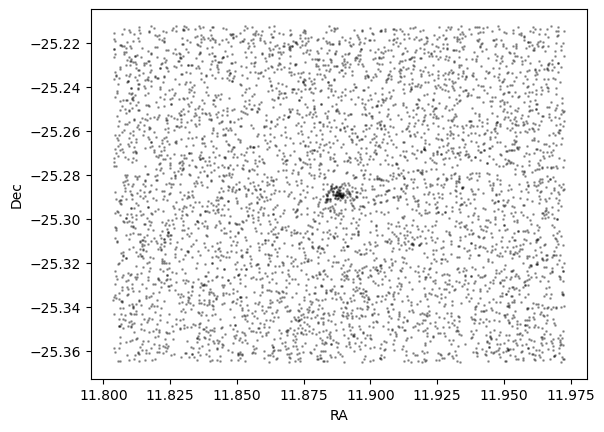

In [31]:
plt.scatter(cat[mask_bkg][inside]['ra'], cat[mask_bkg][inside]['dec'], s=1, c='k', alpha=0.3)

plt.scatter(gal.obj_cat['ra'][mask_ufd], gal.obj_cat['dec'][mask_ufd], s=1, c='k', alpha=0.3)

plt.xlabel('RA')
plt.ylabel('Dec')

In [38]:
np.logspace(np.log10(1 / 3600), np.log10(180 / 3600), 10)

array([0.00027778, 0.00049463, 0.00088078, 0.00156839, 0.00279281,
       0.00497309, 0.00885549, 0.01576879, 0.02807916, 0.05      ])

In [ ]:
np.arange(0.001, 0.3, 0.001)

Text(0, 0.5, 'F158')

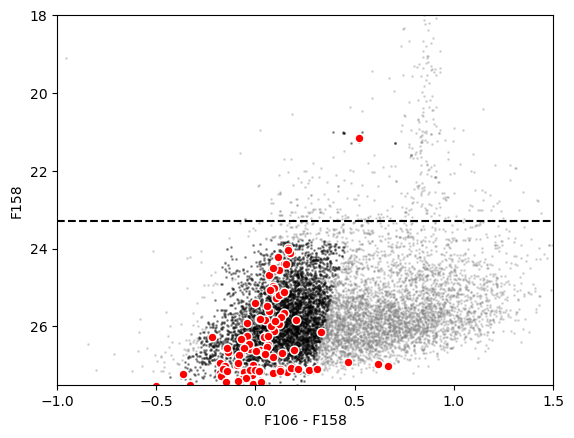

In [32]:
fig, ax = plt.subplots()
plt.axhline(-5.4 + sp.dist_mod + rosesim.Roman_zp_AB_Vega_parsec['F158'], ls='--', c='k')

plt.scatter(c_bkg, m_bkg, s=1, c="gray", alpha=0.25)
plt.scatter(c_bkg[inside], m_bkg[inside], s=1, c="k", alpha=0.25)
plt.scatter(c_ufd, m_ufd, s=40, c="r", alpha=1, ec='w')

plt.ylim(27.5, 18)
plt.xlim(-1, 1.5)
plt.xlabel("F106 - F158")
plt.ylabel("F158")